# Анализ текстовых данных

В этом ноутбуке вы научитесь:
1. Очищать текст (приводить к нижнему регистру, удалять знаки препинания)
2. Проводить лемматизацию ( приводить все слова к основе) с помощью pymorphy3
3. Считать частоту слов
4. Удалять стоп-слова
5. Вычислять TF-IDF слов
6. И даже реализуете свой информационный поиск по Вашему корпусу текста

Сгенерируем небольшой набор данных, представляющий собой 5 положительных и 5 отрицательных отзывов на товар.

In [ ]:
import pandas as pd

data = {
    'category': ['Позитив'] * 5 + ['Негатив'] * 5,
    'text': [
        "Мне всё просто СУПЕР!!! Рекомендую всем",
        "Отличный продукт, очень доволен покупкой",
        "Качество товара на высоте, конечно, буду заказывать ещё",
        "Прекрасно! Лучше для меня не найти, спасибо",
        "Такой хороший товар, также быстрая доставка, рекомендую",
        "Ужасное качество товара, не советую никому",
        "Полное разочарование, деньги на ветер",
        "Не работает, верните деньги! Очень злой",
        "Плохо, очень плохо. Не покупайте это",
        "Худшая покупка в моей жизни, тоже не рекомендую товар"
    ]
}

df = pd.DataFrame(data)
df

,category,text
0,Позитив,Мне всё просто СУПЕР!!! Рекомендую всем
1,Позитив,"Отличный продукт, очень доволен покупкой"
2,Позитив,"Качество товара на высоте, конечно, буду заказ..."
3,Позитив,"Прекрасно! Лучше для меня не найти, спасибо"
4,Позитив,"Такой хороший товар, также быстрая доставка, р..."
5,Негатив,"Ужасное качество товара, не советую никому"
6,Негатив,"Полное разочарование, деньги на ветер"
7,Негатив,"Не работает, верните деньги! Очень злой"
8,Негатив,"Плохо, очень плохо. Не покупайте это"
9,Негатив,"Худшая покупка в моей жизни, тоже не рекоменду..."


## 1. Очистка текста

Прежде всего "очистим" текст.

Компьютер воспринимает `"СУПЕР"`, `"Супер"` и `"супер"` как три разных слова.  Чтобы это исправить, приводим все слова к нижнему регистру.

Также удалим знаки препинания (восклицательные знаки, запятые и т.д.), т.е. они не несут смысла.

Для этого используем регулярные выражения (`re.sub`).

In [ ]:
import re

def clean_text(text):
    text = text.lower()                    # Всё в нижний регистр
    text = re.sub(r'[^а-яё ]', '', text)   # Удаляем всё, кроме русских букв и пробелов
    text = ' '.join(text.split())          # Убираем лишние пробелы
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Покажем, как изменился текст
print(f"До:  {df['text'].iloc[0]}")
print(f"После: {df['clean_text'].iloc[0]}")

До:  Мне всё просто СУПЕР!!! Рекомендую всем
После: мне всё просто супер рекомендую всем


## 2. Лемматизация (приведение слов к начальной форме)

Слова `"заказывать"`, `"заказываю"`, `"заказал"` — для компьютера это разные слова, но для человека это одно и то же.

**Лемматизация** приводит слова к их начальной форме:
- `"заказывать"`, `"заказываю"` → `"заказывать"`
- `"товары"`, `"товаром"` → `"товар"`
- `"лучше"`, `"лучший"` → `"лучший"`

Для русского языка используем библиотеку `pymorphy3` — морфологический анализатор для русского языка. Она умеет определять часть речи, число, падеж и начальную форму слова.

In [ ]:
# Установка библиотеки (раскомментируйте и запустите один! раз)
#!pip install pymorphy3

In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()                     # Создаём анализатор

# Пример работы лемматизации
word = "стали"
parsed = morph.parse(word)[0]                         # одно и тоже слово может иметь разные значения, здесь берется нулевое -- наиболее вероятное
print(f"Слово: {word}")
print(f"Лемма: {parsed.normal_form}")                 # выводим начальную форму слова
print(f"Часть речи: {parsed.tag.POS}")                # часть речи

Слово: стали
Лемма: стать
Часть речи: VERB


In [ ]:
def lemmatize_text(text):
    """
    Разбивает текст на слова и каждое слово приводит к начальной форме.
    """
    words = text.split()                                           # Разбиваем на слова
    lemmas = [morph.parse(word)[0].normal_form for word in words]  # Лемматизируем каждое
    return ' '.join(lemmas)                                        # Собираем обратно в строку

# Применяем функцию ко всем текстам в датасете
df['lemmas'] = df['clean_text'].apply(lemmatize_text)

Выведем таблицу с исходным текстом, после очистки, после лемматизации. Проанализируйте, как менялся текст на каждом этапе.

In [ ]:
df

,category,text,clean_text,lemmas
0,Позитив,Мне всё просто СУПЕР!!! Рекомендую всем,мне всё просто супер рекомендую всем,я всё просто супер рекомендовать весь
1,Позитив,"Отличный продукт, очень доволен покупкой",отличный продукт очень доволен покупкой,отличный продукт очень довольный покупка
2,Позитив,"Качество товара на высоте, конечно, буду заказ...",качество товара на высоте конечно буду заказыв...,качество товар на высота конечно быть заказыва...
3,Позитив,"Прекрасно! Лучше для меня не найти, спасибо",прекрасно лучше для меня не найти спасибо,прекрасно хороший для я не найти спасибо
4,Позитив,"Такой хороший товар, также быстрая доставка, р...",такой хороший товар также быстрая доставка рек...,такой хороший товар также быстрый доставка рек...
5,Негатив,"Ужасное качество товара, не советую никому",ужасное качество товара не советую никому,ужасный качество товар не советовать никто
6,Негатив,"Полное разочарование, деньги на ветер",полное разочарование деньги на ветер,полный разочарование деньга на ветер
7,Негатив,"Не работает, верните деньги! Очень злой",не работает верните деньги очень злой,не работать вернуть деньга очень злой
8,Негатив,"Плохо, очень плохо. Не покупайте это",плохо очень плохо не покупайте это,плохо очень плохо не покупать это
9,Негатив,"Худшая покупка в моей жизни, тоже не рекоменду...",худшая покупка в моей жизни тоже не рекомендую...,плохой покупка в мой жизнь тоже не рекомендова...


## 3. Подсчёт частоты слов

Посмотрим, какие слова встречаются в наших отзывах чаще всего.
Для этого:


*   Объединим все лемматизированные тексты в один список слов
*   Посчитаем частоту каждого слова с помощью Counter
*   Выведем топ-10 самых частых слов

In [ ]:
from collections import Counter

# Объединяем все леммы в один список слов
all_words = ' '.join(df['lemmas']).split()

# Считаем частоту каждого слова
word_counts = Counter(all_words)

print("Топ-10 самых частых слов:")
for word, count in word_counts.most_common(10):
    print(f"{word}: {count}")

Топ-10 самых частых слов:
не: 5
товар: 4
рекомендовать: 3
очень: 3
я: 2
покупка: 2
качество: 2
на: 2
хороший: 2
деньга: 2


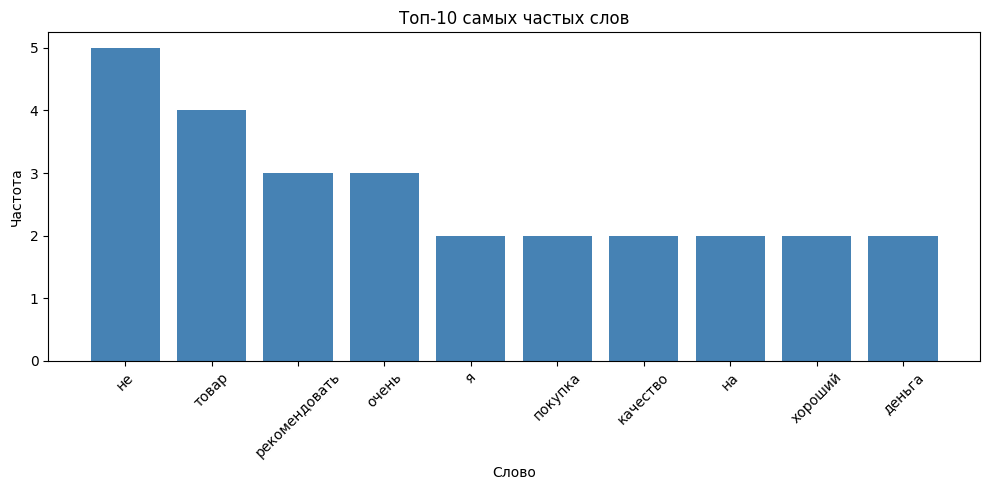

In [ ]:
# Строим столбчатый график топ-10 слов
import matplotlib.pyplot as plt

# Берём топ-10 и разделяем на слова и частоты
top_words = word_counts.most_common(10)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Топ-10 самых частых слов')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Интересную возможность для визуализации дает **облако слов (Word Cloud)** —  способ наглядно показать, какие слова встречаются чаще всего.
**Чем чаще слово**, тем оно **крупнее** на картинке.

Облако слов помогает быстро увидеть:
- Основные темы в текстах
- Какие слова доминируют
- Различия между категориями (если строить отдельно для каждой)

**Параметр `max_words=10`** показывает только топ-10 самых частых слов, чтобы не перегружать картинку. Попробуйте убрать его и построить все слова, будет очень красиво.

In [ ]:
# Установка (один раз)
#!pip install wordcloud

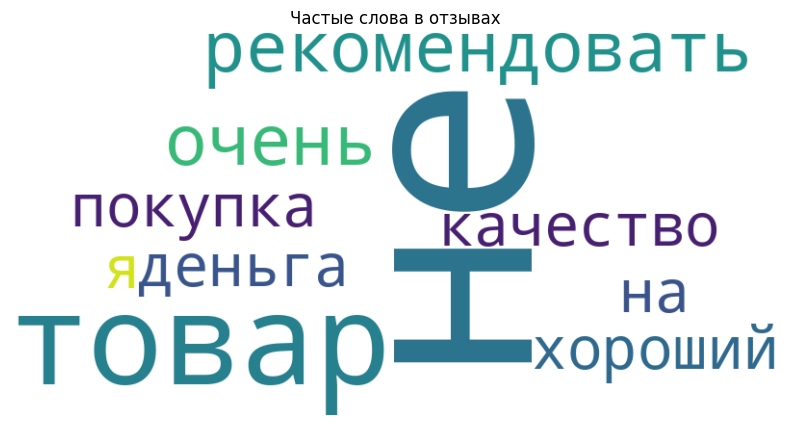

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Создаём облако слов
all_text = ' '.join(df['lemmas'])
wc = WordCloud(width=800, height=400,  max_words=10, background_color='white').generate(all_text)

# Показываем
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Частые слова в отзывах')
plt.show()

Можно построить облака слов для наших категорий - позитивных и негативных отзывов.

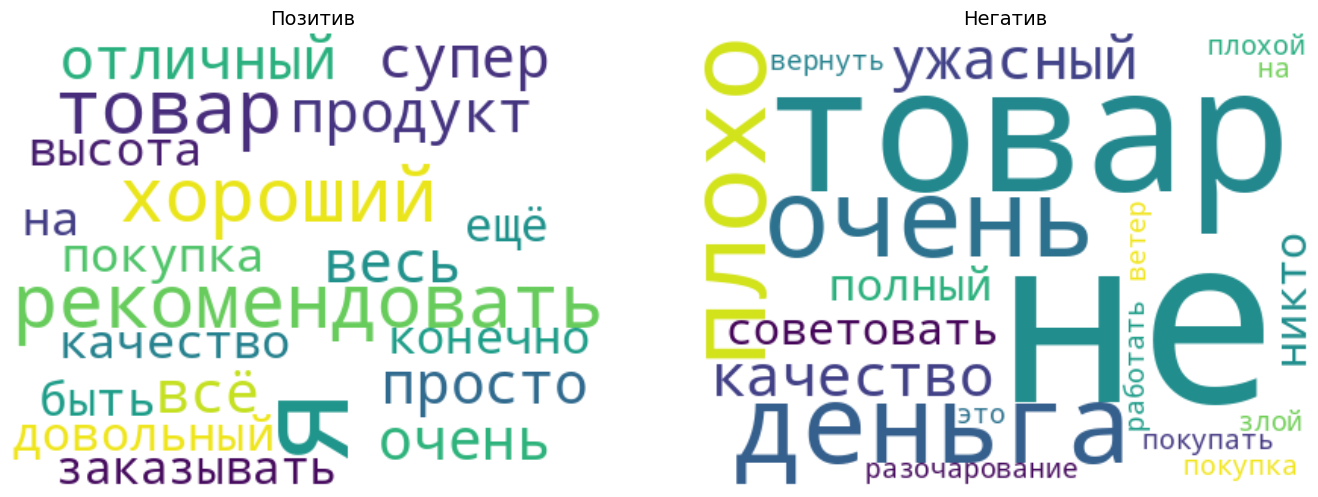

In [ ]:
# Облако слов для "Позитива"
pos_text = ' '.join(df[df['category'] == 'Позитив']['lemmas'])
wc_pos = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(pos_text)

# Облако слов для "Негатива"
neg_text = ' '.join(df[df['category'] == 'Негатив']['lemmas'])
wc_neg = WordCloud(width=400, height=300, background_color='white', max_words=20).generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Позитив', fontsize=14)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Негатив', fontsize=14)

plt.tight_layout()
plt.show()

## 4. Удаление стоп-слов

Как мы видим, самым частым словом у нас оказалось "не".
Слова "не", "и", "в", "на" и т.д. встречаются почти в любом тексте, но не несут полезного смысла для анализа.
Такие слова называют стоп-словами и обычно перед анализом текста их удаляют.
Возьмём готовый список русских стоп-слов из библиотеки nltk.

In [ ]:
import nltk
from nltk.corpus import stopwords

# Скачиваем список стоп-слов
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('russian'))         # загружаем русские стоп-слова

print("Примеры стоп-слов:", list(stop_words)[:20])   # первые 20 стоп-слов

# удаляем стоп-слова из наших лемматизированных текстов
def remove_stopwords(text, stop_words):
    words = text.split()
    return ' '.join([w for w in words if w not in stop_words])

df['no_stopwords'] = df['lemmas'].apply(lambda x: remove_stopwords(x, stop_words))

Примеры стоп-слов: ['я', 'о', 'уже', 'ли', 'эту', 'как', 'ни', 'конечно', 'один', 'разве', 'всю', 'все', 'были', 'когда', 'нибудь', 'нас', 'сейчас', 'нее', 'а', 'ей']


Вновь проанализируйте, как изменился текст после удаления стоп-слов.

In [ ]:
df

,category,text,clean_text,lemmas,no_stopwords
0,Позитив,Мне всё просто СУПЕР!!! Рекомендую всем,мне всё просто супер рекомендую всем,я всё просто супер рекомендовать весь,всё просто супер рекомендовать весь
1,Позитив,"Отличный продукт, очень доволен покупкой",отличный продукт очень доволен покупкой,отличный продукт очень довольный покупка,отличный продукт очень довольный покупка
2,Позитив,"Качество товара на высоте, конечно, буду заказ...",качество товара на высоте конечно буду заказыв...,качество товар на высота конечно быть заказыва...,качество товар высота заказывать ещё
3,Позитив,"Прекрасно! Лучше для меня не найти, спасибо",прекрасно лучше для меня не найти спасибо,прекрасно хороший для я не найти спасибо,прекрасно хороший найти спасибо
4,Позитив,"Такой хороший товар, также быстрая доставка, р...",такой хороший товар также быстрая доставка рек...,такой хороший товар также быстрый доставка рек...,хороший товар также быстрый доставка рекомендо...
5,Негатив,"Ужасное качество товара, не советую никому",ужасное качество товара не советую никому,ужасный качество товар не советовать никто,ужасный качество товар советовать никто
6,Негатив,"Полное разочарование, деньги на ветер",полное разочарование деньги на ветер,полный разочарование деньга на ветер,полный разочарование деньга ветер
7,Негатив,"Не работает, верните деньги! Очень злой",не работает верните деньги очень злой,не работать вернуть деньга очень злой,работать вернуть деньга очень злой
8,Негатив,"Плохо, очень плохо. Не покупайте это",плохо очень плохо не покупайте это,плохо очень плохо не покупать это,плохо очень плохо покупать это
9,Негатив,"Худшая покупка в моей жизни, тоже не рекоменду...",худшая покупка в моей жизни тоже не рекомендую...,плохой покупка в мой жизнь тоже не рекомендова...,плохой покупка жизнь рекомендовать товар


## 5. TF-IDF: превращаем текст в числа

Компьютер не работает со словами — только с числами. Поэтому каждый текст нужно представить в виде вектора чисел. Мы воспользуемя векторайзером TfidfVectorizer, который для каждого слова вычислит "вес" TF-IDF.

Подробно о векторизации текста Вы узнает в ходе дальнейшего обучения, пока нам можно считать, что TF-IDF состоит из TF (Term Frequency), которая показывает как часто слово встречается в этом тексте и IDF (Inverse Document Frequency), которая показывает, насколько редким является слово во всем наборе данных.

Высокий вес **TF-IDF = TF × IDF**  получается, когда слово часто встречается в *этом* отзыве и редко встречается в *остальных* отзывах.  


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# создаём и обучаем векторайзер
vectorizer = TfidfVectorizer(stop_words=list(stop_words))  # обычно именно тут удаляют стоп-слова, а не ранее, как это сделали мы
tfidf_matrix = vectorizer.fit_transform(df['no_stopwords'])

# получаем список всех слов (словарь)
feature_names = vectorizer.get_feature_names_out()
print(f"Размер словаря: {len(feature_names)} слов")

Размер словаря: 37 слов


Мы собрали все слова из всех текстов в длинный список, у нас получилось 37 слов. Вот так выглядит сам словарь.

In [ ]:
feature_names

array(['быстрый', 'вернуть', 'весь', 'ветер', 'всё', 'высота', 'деньга',
       'довольный', 'доставка', 'ещё', 'жизнь', 'заказывать', 'злой',
       'качество', 'найти', 'никто', 'отличный', 'очень', 'плохо',
       'плохой', 'покупать', 'покупка', 'полный', 'прекрасно', 'продукт',
       'просто', 'работать', 'разочарование', 'рекомендовать',
       'советовать', 'спасибо', 'супер', 'также', 'товар', 'ужасный',
       'хороший', 'это'], dtype=object)

Теперь каждый текст в нашем наборе данных представляет собой вектор длины 37, значения элементов которого есть TF-IDF слов словаря. Ниже приведен пример первого текста из 5 слов. Соответствующий ему вектор длины 37 содержит ровно 5 ненулевых элементов со значениями TF-IDF этих слов. Если слова нет в тексте, его TF-IDF равен нулю.


In [ ]:
# наш первый отзыв в виде вектора
print(f"Текст: {df['no_stopwords'].iloc[0]}")
print(f"Вектор:\n{tfidf_matrix[0].toarray()}")

Текст: всё просто супер рекомендовать весь
Вектор:
[[0.         0.         0.46864588 0.         0.46864588 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.46864588 0.         0.         0.34854576 0.
  0.         0.46864588 0.         0.         0.         0.
  0.        ]]


Теперь тексты можно сравнивать, искать, классифицировать и т.д.

## 6. Информационный поиск

Найдем тексты, которые **наиболее похожи** на поисковый запрос или, другими словами, найдем вектора наших текстов **наиболее похожие** на вектор запроса.

Для измерения похожести векторов обычно используется **косинусное сходство** (cosine similarity), которое равно **1**, если векторы одинаковые.
Подробнее об этой метрике и других Вы также узнаете в ходе дальнейшего обучения.

Реализуем простой поиск.

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# функция поиска наиболее близких текстов к запросу
def search_texts(query, vectorizer, tfidf_matrix, texts, top_n=3):
    """
    Ищет top_n текстов, наиболее похожих на запрос.
    """
    query = clean_text(query)            # очищаем запрос
    query = lemmatize_text(query)        # лемматизируем запрос
    query_vec = vectorizer.transform([query])  # векторизуем запрос

    # считаем похожесть запроса со всеми текстами
    similarities = cosine_similarity(query_vec, tfidf_matrix)[0]

    # находим индексы топ-n самых похожих
    top_indices = similarities.argsort()[-top_n:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            'Текст': texts.iloc[idx],
            'Похожесть': similarities[idx]
        })

    return results

Приведем пример использования функции поиска. Предположим пользователь вводит в строке поиска "Качество товара".
Найдем текст в нашем наборе данных наиболее близкий к данному запросу.

In [ ]:
# Пример поиска
query = "Качество товара"
results = search_texts(query, vectorizer, tfidf_matrix, df['no_stopwords'], top_n=3)

print(f"Поисковый запрос: '{query}'")
print(f"\nНайдено {len(results)} наиболее похожих отзывов:\n")
for i, res in enumerate(results, 1):
    print(f"{i}. Похожесть: {res['Похожесть']:.8f}")
    print(f"   Текст: {res['Текст']}")

Поисковый запрос: 'Качество товара'

Найдено 3 наиболее похожих отзывов:

1. Похожесть: 0.52803897
   Текст: качество товар высота заказывать ещё
2. Похожесть: 0.52803897
   Текст: ужасный качество товар советовать никто
3. Похожесть: 0.21068519
   Текст: плохой покупка жизнь рекомендовать товар


Проанализируйте полученный результат. Первыми были выведены те тексты, которые содержали оба слова из запроса. Какая похожесть у этих текстов? Что можно сказать о третьем тексте?

# Задание

**Найти текстовый набор данных**, в соответствии с файлом инструкцией, в котором изложены требования.


Примените все 6 шагов из учебного ноутбука к Вашему датасету (лучше, чтобы язык был русский. В противном случае вместо pymorphy используйте nltk и spacy).

**1. Очистка текста**
- Приведите к нижнему регистру
- Удалите знаки препинания и лишние пробелы
- Выведите 2–3 примера до и после очистки

**2. Лемматизация**
- Примените pymorphy3 ко всем текстам
- Выведите 2–3 примера до и после лемматизации

**3. Подсчёт частоты слов**
- Посчитайте топ-10 самых частых слов
- Постройте столбчатый график
- Постройте облако слов (WordCloud)

**4. Удаление стоп-слов**
- Загрузите список стоп-слов
- Удалите их из текстов
- Посчитайте топ-10 слов после удаления
- Выведите примеры текстов до и после

**5. TF-IDF**
- Векторизуйте тексты через TfidfVectorizer
- Выведите размер словаря
- Покажите пример вектора для одного текста

**6. Информационный поиск**
- Реализуйте функцию поиска
- Протестируйте на 2–3 запросах
- Покажите результаты поиска (текст + похожесть)
